In [1]:
import math

def logsumexp2(x, y):
    m = x if x > y else y
    return m + math.log(math.exp(x - m) + math.exp(y - m))

def logsumexp_list(vals):
    m = max(vals)
    s = 0.0
    for v in vals:
        s += math.exp(v - m)
    return m + math.log(s)

def log1mexp_neg(x):
    # x <= 0 ; returns log(1 - exp(x)) stably
    # here x = k*log(b), with b in (0,1), so x<0
    return math.log(-math.expm1(x))

def log_Q(n, b):
    if not (0.0 < b < 1.0):
        raise ValueError("b must lie in (0,1)")
    
    logb = math.log(b)

    # L_prev[i] stores L(m-1, i+1) in 0-based Python indexing
    L_prev = [0.0]   # m=1: only L(1,1)=0

    # build up to m = n+1, because H_n = F(n+1, n+1)
    for m in range(2, n + 2):
        L = [0.0] * m

        # L(m,m)
        L[m - 1] = logsumexp_list(L_prev)

        # L(m,i), i = m-1, m-2, ..., 1
        log1mbpow = log1mexp_neg((m - 1) * logb)   # log(1 - b^(m-1))
        for i in range(m - 1, 0, -1):
            # Python index i-1 corresponds to mathematical i
            t1 = logb + L[i]                       # log( b * F(m, i+1) )
            t2 = (1 - i) * logb + log1mbpow + L_prev[i - 1]
            L[i - 1] = logsumexp2(t1, t2)

        L_prev = L

    logH = L_prev[n]   # this is log F(n+1, n+1) = log H_n(b,1/b)

    # log (b;b)_n = sum_{k=1}^n log(1 - b^k)
    log_poch = 0.0
    for k in range(1, n + 1):
        log_poch += log1mexp_neg(k * logb)

    return (n * (n + 1) // 2) * logb - 2.0 * log_poch + logH

In [5]:
def getb(N,tau):
    epsilon = tau / N
    zeta = 1.0 + 0.5 * epsilon * epsilon
    u = math.log(zeta + math.sqrt(zeta * zeta - 1.0))
    b = math.exp(-N * u)
    return b

In [4]:
N = 200_000
n = 10_000
(log_Q(n,getb(N,4)) - log_Q(n,getb(N,4.5)))/0.5

KeyboardInterrupt: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import pandas as pd

save_filename = "EvsTauPA2D_T.csv"


def energy(n, verbose=False):
    cur_lvl = 0
    total_eng = 0
    m = n
    while n > 0:
        for i in range(0, cur_lvl):
            if n > 0:
                total_eng += cur_lvl - 1
                n -= 1
            else:
                break
        cur_lvl += 1
    if verbose:
        print("Highest shell: ", cur_lvl)
    return total_eng + m   # + m #- (m*(m-1))//2






# 1. Top level helper function
def _calc_log_q_worker(args):
    tau_val, n, N = args
    return log_Q(n, getb(N, tau_val))

# 2. Main function
def plot_fd_vs_tau(n, N_list, tau_start, tau_end, tau_step):
    if tau_step <= 0:
        raise ValueError("tau_step must be positive")
    if tau_end <= tau_start:
        raise ValueError("tau_end must be greater than tau_start")

    taus_left = np.arange(tau_start, tau_end, tau_step)
    taus_left = taus_left[taus_left + tau_step <= tau_end + 1e-15]
    taus_mid = taus_left + 0.5 * tau_step
    
    plt.figure(figsize=(8, 5))

    data_columns = [taus_mid]
    headers = ["tau_mid"]
    
    for N in N_list:
        taus_full = np.append(taus_left, taus_left[-1] + tau_step)
        tasks = [(tau, n, N) for tau in taus_full]

        # Use joblib's Parallel and delayed. 
        # n_jobs=-1 tells it to use all available CPU cores.
        logq_list = Parallel(n_jobs=-1)(delayed(_calc_log_q_worker)(task) for task in tasks)
        logq_vals = np.array(logq_list)
    
        ys = (logq_vals[:-1] - logq_vals[1:]) / tau_step
        data_columns.append(ys)
        headers.append(f"N_{N}")
        plt.plot(taus_mid, ys, label=f"N={N}")

    e = energy(n)
    plt.axhline(e, linestyle='--', label=f"energy(n)={e}")

    plt.xlabel(r"$\tau + \frac{1}{2}\,\Delta\tau$")
    plt.ylabel(r"$[\log Q(\tau)-\log Q(\tau+\Delta\tau)]/\Delta\tau$")
    plt.title(f"Finite difference of log_Q vs tau midpoint (n={n})")
    plt.legend()
    plt.ylim(4650,5150)
    plt.xlim(0,15)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Combine the columns into a 2D numpy array (table format)
    # Shape will be (number_of_tau_points, 1 + len(N_list))
    data_table = np.column_stack(data_columns)
    
    # Save the array to a binary .npy file
    df = pd.DataFrame(data_table, columns=headers)
    df.to_csv(save_filename, index=False)
    print(f"Data successfully saved to '{save_filename}'.")

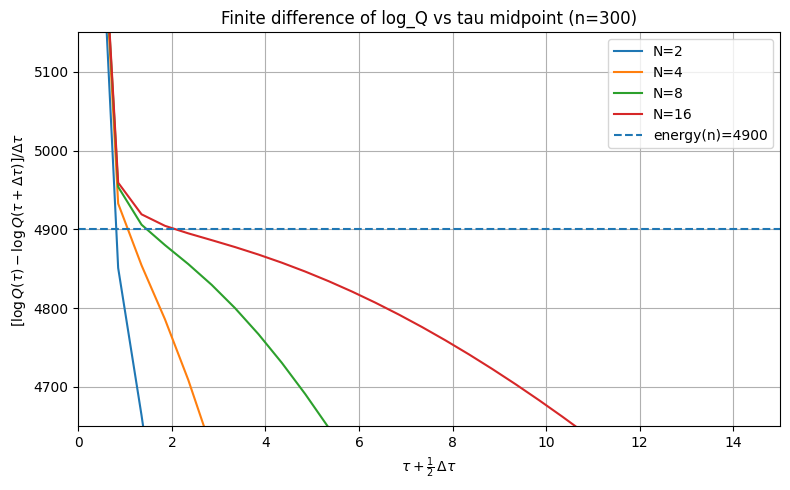

Data successfully saved to 'EvsTauPA2D.csv'.


In [28]:
N_list = [2,4,8,16]
n = 300

plot_fd_vs_tau(
    n=n,
    N_list=N_list,
    tau_start=0.1,
    tau_end=15,
    tau_step=0.5
)

In [2]:
import numba

@numba.njit
def logsumexp2(x, y):
    m = x if x > y else y
    return m + math.log(math.exp(x - m) + math.exp(y - m))

@numba.njit
def logsumexp_array(vals):
    # Numba optimized version of logsumexp_list
    m = np.max(vals)
    s = 0.0
    for i in range(len(vals)):
        s += math.exp(vals[i] - m)
    return m + math.log(s)

@numba.njit
def log1mexp_neg(x):
    # x <= 0 ; returns log(1 - exp(x)) stably
    return math.log(-math.expm1(x))

@numba.njit
def log_Q(n, b):
    if not (0.0 < b < 1.0):
        raise ValueError("b must lie in (0,1)")
    
    logb = math.log(b)

    # FIX 1: Pre-allocate 1D NumPy arrays up to size n+2.
    # This prevents creating millions of lists and fragmented float objects in RAM.
    L_prev = np.zeros(n + 2, dtype=np.float64)
    L = np.zeros(n + 2, dtype=np.float64)

    # m=1: L(1,1)=0, which is naturally handled as L_prev[0] is initialized to 0.0

    for m in range(2, n + 2):
        # L(m,m)
        # We slice L_prev[:m-1] to pass only the valid populated data from the last step
        L[m - 1] = logsumexp_array(L_prev[:m - 1])

        # L(m,i), i = m-1, m-2, ..., 1
        log1mbpow = log1mexp_neg((m - 1) * logb)   
        for i in range(m - 1, 0, -1):
            t1 = logb + L[i]                       
            t2 = (1 - i) * logb + log1mbpow + L_prev[i - 1]
            L[i - 1] = logsumexp2(t1, t2)

        # Swap array pointers (fast) instead of allocating a new array
        # We don't need to zero out L because the inner loop explicitly overwrites indices 0 to m-1
        temp = L_prev
        L_prev = L
        L = temp

    logH = L_prev[n]

    # log (b;b)_n = sum_{k=1}^n log(1 - b^k)
    log_poch = 0.0
    for k in range(1, n + 1):
        log_poch += log1mexp_neg(k * logb)

    return (n * (n + 1) // 2) * logb - 2.0 * log_poch + logH

In [3]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed


def energy(n, w, verbose=False):
    """
    Computes the exact energy for n fermions in a 2D harmonic trap, 
    scaled by the effective relative frequency w.
    """
    # 1. Compute the standard base energy (w=1) using your exact state-filling logic
    cur_lvl = 0
    total_eng = 0
    m = n
    while n > 0:
        for i in range(0, cur_lvl):
            if n > 0:
                total_eng += cur_lvl - 1
                n -= 1
            else:
                break
        cur_lvl += 1
        
    base_energy = total_eng + m   
    
    if verbose:
        print("Highest shell: ", cur_lvl)
        
    # 2. Scale the relative energy component by w
    # For a 2D harmonic oscillator, the 1-particle CM energy is exactly 1.0
    e_1 = 1.0 
    
    true_energy_w = e_1 + w * (base_energy - e_1)
    
    return true_energy_w

# ==========================================
# 1. PA Propagator Functions
# ==========================================
def p_funcs_zeta_1(e):
    return 1.0 + (e**2) / 2.0

def p_funcs_lambda(e):
    return 1.0

def p_funcs_gamma(e):
    return math.sqrt(1.0 + (e**2) / 4.0)

def p_funcs_k1(e):
    return e

# ==========================================
# 2. Factor Calculations
# ==========================================
def factor_calc_T(lambda_val, gamma_val, w, lambda_val_s, gamma_val_s):
    return (lambda_val / gamma_val), (w * lambda_val_s / gamma_val_s)

def factor_calc_H(lambda_val, gamma_val, w, lambda_val_s, gamma_val_s):
    return 0.5 * (gamma_val + 1.0 / gamma_val), (w / 2.0) * (gamma_val_s + 1.0 / gamma_val_s)

# ==========================================
# 3. Top-Level Worker Function (Finite Diff)
# ==========================================
def _compute_estimators_worker_fd(args):
    tau_mid, tau_step, n, N, w = args
    
    # Left and right tau for the discrete derivative
    tau_1 = tau_mid - 0.5 * tau_step
    tau_2 = tau_mid + 0.5 * tau_step
    
    # --- A. Evaluate Factors at the midpoint ---
    epsilon = tau_mid / N
    eps_s = w * epsilon
    
    lambda_val = p_funcs_lambda(epsilon)
    gamma_val = p_funcs_gamma(epsilon)
    
    lambda_val_s = p_funcs_lambda(eps_s)
    zeta_1_s = p_funcs_zeta_1(eps_s)
    k1_s = p_funcs_k1(eps_s)
    
    # Guard against domain error in sqrt
    gamma_val_s = math.sqrt(max(0, zeta_1_s**2 - 1.0)) / k1_s
    
    fT_reg, fT_star = factor_calc_T(lambda_val, gamma_val, w, lambda_val_s, gamma_val_s)
    fH_reg, fH_star = factor_calc_H(lambda_val, gamma_val, w, lambda_val_s, gamma_val_s)
    
    # --- B. Compute Energies using YOUR Discrete Derivative ---
    def fd_log_Q(num_particles, b1, b2):
        """Finite difference derivative: [log_Q(tau1) - log_Q(tau2)] / step"""
        lq1 = log_Q(num_particles, b1)
        lq2 = log_Q(num_particles, b2)
        return (lq1 - lq2) / tau_step

    def get_b_val(tau_val, N_val, w_val):
        eps = w_val * (tau_val / N_val)
        z1 = p_funcs_zeta_1(eps)
        u = math.acosh(z1) if z1 >= 1.0 else 0.0
        return math.exp(-N_val * u)
        
    b_tau1 = get_b_val(tau_1, N, 1.0)
    b_tau2 = get_b_val(tau_2, N, 1.0)
    
    b_s_tau1 = get_b_val(tau_1, N, w)
    b_s_tau2 = get_b_val(tau_2, N, w)

    # Because these use finite difference w.r.t tau, these ARE the Thermodynamic energies!
    energy1_T     = fd_log_Q(1, b_tau1, b_tau2)
    energy1star_T = fd_log_Q(1, b_s_tau1, b_s_tau2)
    energystar_T  = fd_log_Q(n, b_s_tau1, b_s_tau2)
    
    # --- C. Assemble Final Estimators ---
    
    # 1. Total Thermodynamic Estimator
    # No factors needed here, the discrete derivative already contains them!
    energy_T = energy1_T + (energystar_T - energy1star_T)
    
    # 2. Total Hamiltonian Estimator
    # We apply your logic: multiply by inverse thermo factor (1/fT), then by Hamiltonian factor (fH)
    energy1_H = energy1_T * (fH_reg / fT_reg)
    energystar_diff_H = (energystar_T - energy1star_T) * (fH_star / fT_star)
    
    energy_H = energy1_H + energystar_diff_H
    
    return energy_T, energy_H

# ==========================================
# 4. Main Plotting & Saving Function
# ==========================================
def plot_fd_vs_tau_dual(n, N_list, w, tau_start, tau_end, tau_step, save_filename="plot_data"):
    if tau_step <= 0:
        raise ValueError("tau_step must be positive")
    if tau_end <= tau_start:
        raise ValueError("tau_end must be greater than tau_start")

    taus_left = np.arange(tau_start, tau_end, tau_step)
    taus_left = taus_left[taus_left + tau_step <= tau_end + 1e-15]
    taus_mid = taus_left + 0.5 * tau_step
    
    plt.figure(figsize=(10, 6))
    
    # Initialize dictionaries to hold our results for CSV
    results_T = {"tau_mid": taus_mid}
    results_H = {"tau_mid": taus_mid}
    
    for N in N_list:
        tasks = [(tau, tau_step, n, N, w) for tau in taus_mid]

        # Use joblib to compute estimators in parallel
        results = Parallel(n_jobs=-1)(delayed(_compute_estimators_worker_fd)(task) for task in tasks)
        
        energies_T = np.array([res[0] for res in results])
        energies_H = np.array([res[1] for res in results])
        
        results_T[f"N_{N}"] = energies_T
        results_H[f"N_{N}"] = energies_H
        
        # Plot Thermodynamic as solid lines, Hamiltonian as dashed
        line, = plt.plot(taus_mid, energies_T, label=f"N={N} (Thermo)")
        plt.plot(taus_mid, energies_H, linestyle="--", color=line.get_color(), label=f"N={N} (Ham)")

    # Try to plot baseline energy if the `energy(n)` function is defined in your notebook
    try:
        e = energy(n,w)
        plt.axhline(e, linestyle=':', color='black', label=f"True Energy (n={n})")
    except NameError:
        pass 

    plt.xlabel(r"$\tau + \frac{1}{2}\,\Delta\tau$")
    plt.ylabel(r"Energy Estimators")
    plt.title(f"Thermodynamic (Solid) & Hamiltonian (Dashed) via Finite Difference\n(n={n}, w={w}, PA Propagator)")
    
    # Put legend outside the plot so it doesn't overlap lines
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Adjust axes limits as needed based on your n
    plt.ylim(e*0.95, e*1.05) 
    # plt.xlim(0, 15)
    
    plt.grid(True)
    plt.tight_layout()
    #plt.ylim(4650,5150)
    plt.show()
    
    # Convert to pandas DataFrames and save to CSV
    df_T = pd.DataFrame(results_T)
    df_H = pd.DataFrame(results_H)
    
    df_T.to_csv(f"{save_filename}_T.csv", index=False)
    df_H.to_csv(f"{save_filename}_H.csv", index=False)
    
    print(f"Data successfully saved to '{save_filename}_T.csv' and '{save_filename}_H.csv'")
    
    return df_T, df_H

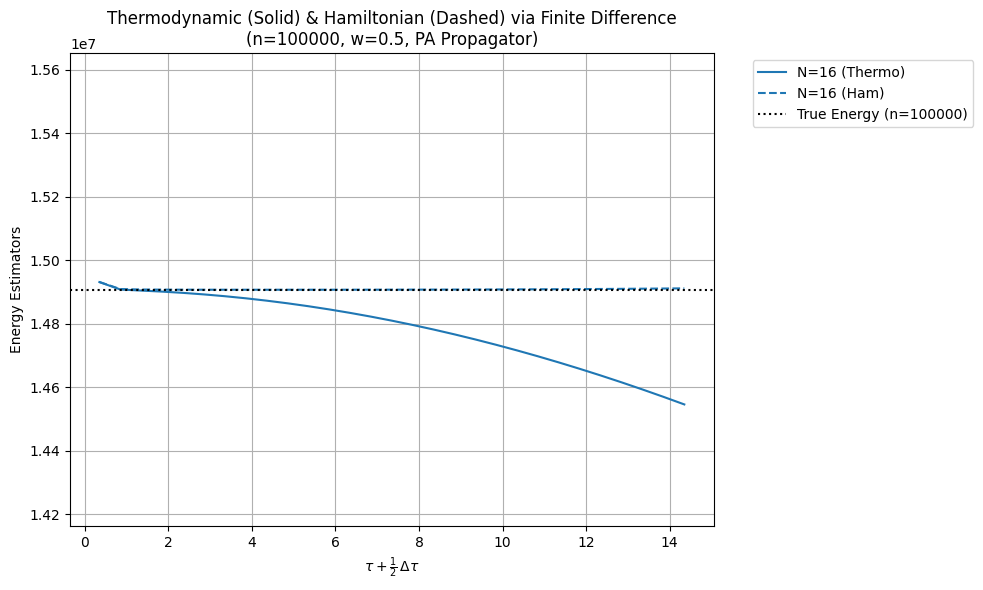

Data successfully saved to 'plot_data_T.csv' and 'plot_data_H.csv'


(    tau_mid          N_16
 0      0.35  1.493135e+07
 1      0.85  1.490801e+07
 2      1.35  1.490462e+07
 3      1.85  1.490131e+07
 4      2.35  1.489733e+07
 5      2.85  1.489252e+07
 6      3.35  1.488685e+07
 7      3.85  1.488030e+07
 8      4.35  1.487286e+07
 9      4.85  1.486454e+07
 10     5.35  1.485534e+07
 11     5.85  1.484526e+07
 12     6.35  1.483430e+07
 13     6.85  1.482248e+07
 14     7.35  1.480979e+07
 15     7.85  1.479624e+07
 16     8.35  1.478185e+07
 17     8.85  1.476661e+07
 18     9.35  1.475054e+07
 19     9.85  1.473364e+07
 20    10.35  1.471593e+07
 21    10.85  1.469741e+07
 22    11.35  1.467809e+07
 23    11.85  1.465798e+07
 24    12.35  1.463709e+07
 25    12.85  1.461544e+07
 26    13.35  1.459302e+07
 27    13.85  1.456986e+07
 28    14.35  1.454596e+07,
     tau_mid          N_16
 0      0.35  1.493157e+07
 1      0.85  1.490933e+07
 2      1.35  1.490794e+07
 3      1.85  1.490754e+07
 4      2.35  1.490737e+07
 5      2.85  1.490729e+07


In [7]:
N_list = [16]
n = 100000
w = 0.5

plot_fd_vs_tau_dual(
    n=n,
    N_list=N_list,
    w=w,
    tau_start=0.1,
    tau_end=15,
    tau_step=0.5
)

In [ ]:
df_T = pd.DataFrame(results_T)
df_H = pd.DataFrame(results_H)

df_T.to_csv(f"{save_filename}_T.csv", index=False)
df_H.to_csv(f"{save_filename}_H.csv", index=False)

In [ ]:
import time
from scipy.optimize import curve_fit

save_filename = "bench_t_vs_n_baxtermeth"

def runtime_scaling_plot(tau, N, nstart, nend, nstep, repeats=1):
    """
    Measure runtime of log_Q(n, getb(N, tau)) as a function of n, and fit

        runtime(n) = a * n^b + c

    Parameters
    ----------
    tau : float
    N : int
    nstart, nend, nstep : int
        n values used are range(nstart, nend + 1, nstep)
    repeats : int
        Number of timings per n; the minimum is used.

    Returns
    -------
    n_vals : np.ndarray
    runtimes : np.ndarray
    fit_params : tuple or None
        (a, b, c) if fitting succeeded, else None
    """
    bval = getb(N, tau)
    n_vals = np.arange(nstart, nend + 1, nstep, dtype=int)
    runtimes = []

    for n in n_vals:
        best = float("inf")
        for _ in range(repeats):
            t0 = time.perf_counter()
            _ = log_Q(int(n), bval)
            t1 = time.perf_counter()
            best = min(best, t1 - t0)
        runtimes.append(best)

    runtimes = np.array(runtimes, dtype=float)

    def model(n, a, b, c):
        return a * np.power(n, b) + c

    fit_params = None

    if len(n_vals) >= 4:
        c0 = max(0.0, float(np.min(runtimes)) * 0.5)
        y0 = np.maximum(runtimes - c0, 1e-12)
        x0 = np.maximum(n_vals.astype(float), 1.0)

        b0 = 2.0
        try:
            coeffs = np.polyfit(np.log(x0), np.log(y0), 1)
            b0 = max(0.1, float(coeffs[0]))
            a0 = math.exp(float(coeffs[1]))
        except Exception:
            a0 = max(1e-12, float(runtimes[-1]) / max(float(n_vals[-1]) ** b0, 1.0))

        try:
            popt, _ = curve_fit(
                model,
                n_vals.astype(float),
                runtimes,
                p0=(a0, b0, c0),
                maxfev=20000
            )
            fit_params = tuple(float(x) for x in popt)
        except Exception:
            fit_params = None

    plt.figure(figsize=(10, 6))
    plt.scatter(n_vals, runtimes, label="measured runtime")

    bench = {"n_vals": n_vals}
    bench["runtimes"] = runtimes
    df = pd.DataFrame(bench)
    df.to_csv(f"{save_filename}.csv", index=False)

    if fit_params is not None:
        a, b_exp, c = fit_params
        n_fine = np.linspace(float(n_vals[0]), float(n_vals[-1]), 400)
        plt.plot(
            n_fine,
            model(n_fine, a, b_exp, c),
            label=f"fit: a*n^b + c\na={a:.6g}, b={b_exp:.6g}, c={c:.6g}"
        )

    plt.title(f"Runtime scaling at tau={tau}, N={N}")
    plt.xlabel("n")
    plt.ylabel("runtime (seconds)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    if fit_params is not None:
        a, b_exp, c = fit_params
        print(f"a = {a}")
        print(f"b = {b_exp}")
        print(f"c = {c}")

    #return n_vals, runtimes, fit_params

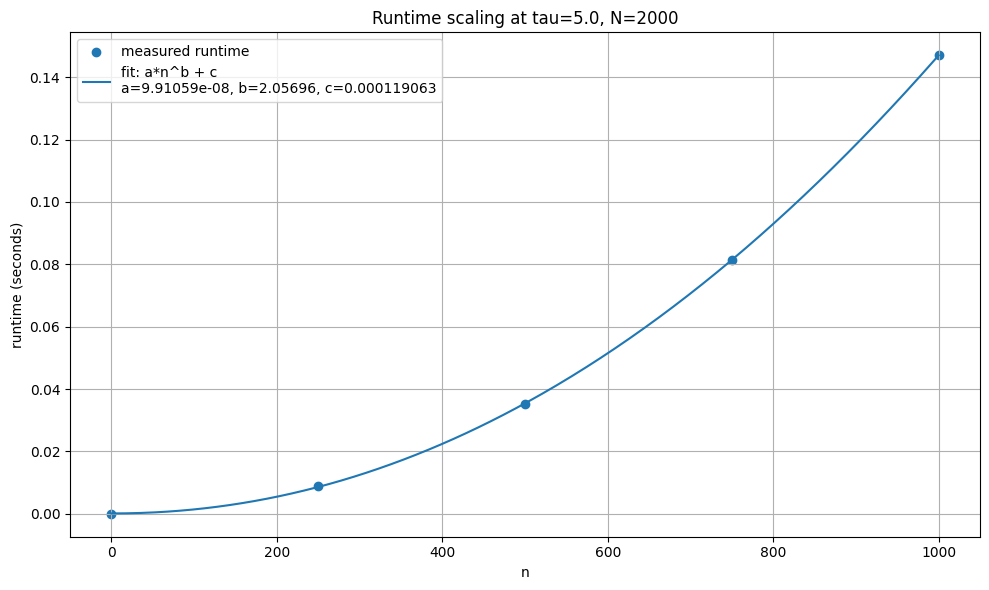

a = 9.910587878965289e-08
b = 2.056957711832276
c = 0.00011906323986420255


In [9]:
runtime_scaling_plot(tau=5.0, N=2000, nstart=0, nend=1000, nstep=250, repeats=3)

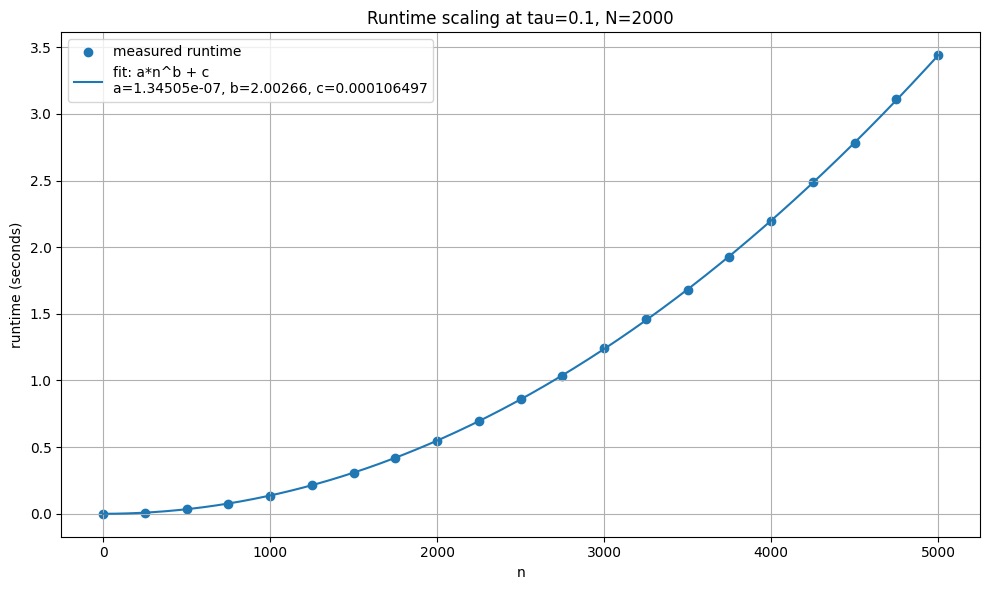

a = 1.3450472570149398e-07
b = 2.002661542745681
c = 0.0001064970757696447


In [10]:
runtime_scaling_plot(tau=0.1, N=2000, nstart=0, nend=5000, nstep=250, repeats=3)

In [120]:
def runtime_scaling_tau_plot(N, n, taustart, tauend, taustep, repeats=1):
    """
    Measure runtime of log_Q(n, getb(N, tau)) as a function of tau, and fit

        runtime(tau) = a * tau^b + c

    Parameters
    ----------
    N : int
    n : int
    taustart, tauend, taustep : float
        tau values used are np.arange(taustart, tauend + taustep, taustep)
    repeats : int
        Number of timings per tau; the minimum is used.

    Returns
    -------
    tau_vals : np.ndarray
    runtimes : np.ndarray
    fit_params : tuple or None
        (a, b, c) if fitting succeeded, else None
    """
    tau_vals = np.arange(taustart, tauend + 0.5 * taustep, taustep, dtype=float)
    runtimes = []

    for tau in tau_vals:
        bval = getb(N, tau)
        best = float("inf")
        for _ in range(repeats):
            t0 = time.perf_counter()
            _ = log_Q(int(n), bval)
            t1 = time.perf_counter()
            best = min(best, t1 - t0)
        runtimes.append(best)

    runtimes = np.array(runtimes, dtype=float)

    def model(tau, a, b, c):
        return a * np.power(tau, b) + c

    fit_params = None

    if len(tau_vals) >= 4:
        c0 = max(0.0, float(np.min(runtimes)) * 0.5)
        y0 = np.maximum(runtimes - c0, 1e-12)
        x0 = np.maximum(tau_vals.astype(float), 1e-12)

        b0 = 1.0
        try:
            coeffs = np.polyfit(np.log(x0), np.log(y0), 1)
            b0 = max(0.1, float(coeffs[0]))
            a0 = math.exp(float(coeffs[1]))
        except Exception:
            a0 = max(1e-12, float(runtimes[-1]) / max(float(tau_vals[-1]) ** b0, 1.0))

        try:
            popt, _ = curve_fit(
                model,
                tau_vals.astype(float),
                runtimes,
                p0=(a0, b0, c0),
                maxfev=20000
            )
            fit_params = tuple(float(x) for x in popt)
        except Exception as e:
            print("Fit failed:", repr(e))
            fit_params = None

    plt.figure(figsize=(10, 6))
    plt.scatter(tau_vals, runtimes, label="measured runtime")

    if fit_params is not None:
        a, b_exp, c = fit_params
        tau_fine = np.linspace(float(tau_vals[0]), float(tau_vals[-1]), 400)
        plt.plot(
            tau_fine,
            model(tau_fine, a, b_exp, c),
            label=f"fit: a*tau^b + c\na={a:.6g}, b={b_exp:.6g}, c={c:.6g}"
        )

    plt.title(f"Runtime scaling in tau at n={n}, N={N}")
    plt.xlabel("tau")
    plt.ylabel("runtime (seconds)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    if fit_params is not None:
        a, b_exp, c = fit_params
        print(f"a = {a}")
        print(f"b = {b_exp}")
        print(f"c = {c}")

    #return tau_vals, runtimes, fit_params

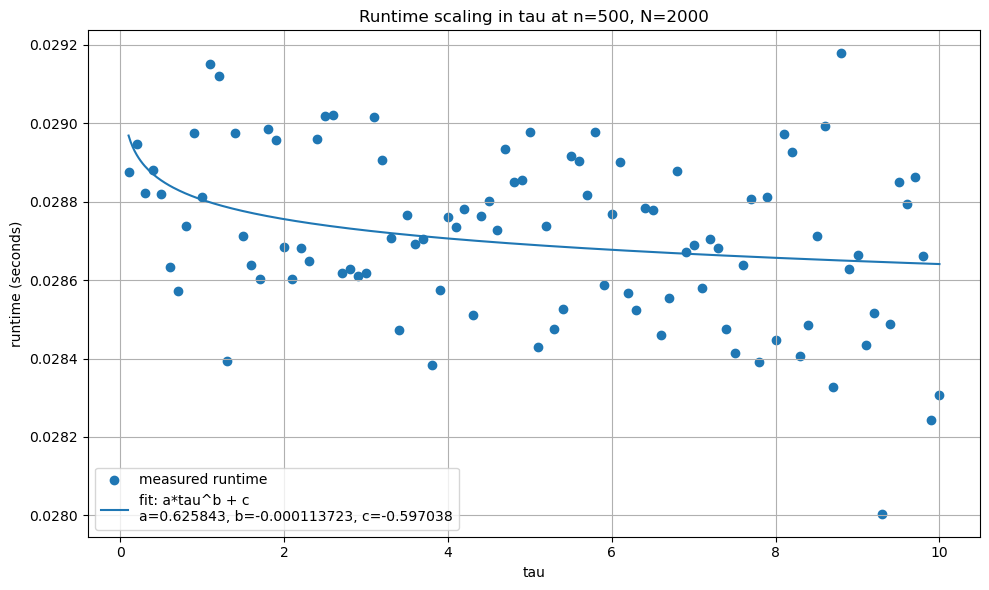

a = 0.6258426797354577
b = -0.00011372281364768256
c = -0.597037705255227


In [123]:
runtime_scaling_tau_plot(N=2000, n=500, taustart=0.1, tauend=10.0, taustep=0.1, repeats=25)

In [126]:
def runtime_scaling_N_plot(tau, n, Nstart, Nend, Nstep, repeats=1):
    """
    Measure runtime of log_Q(n, getb(N, tau)) as a function of N, and fit

        runtime(N) = a * N^b + c

    Parameters
    ----------
    tau : float
    n : int
    Nstart, Nend, Nstep : int
        N values used are np.arange(Nstart, Nend + Nstep, Nstep)
    repeats : int
        Number of timings per N; the minimum is used.

    Returns
    -------
    N_vals : np.ndarray
    runtimes : np.ndarray
    fit_params : tuple or None
        (a, b, c) if fitting succeeded, else None
    """
    N_vals = np.arange(Nstart, Nend + 1, Nstep, dtype=int)
    runtimes = []

    for N in N_vals:
        bval = getb(int(N), tau)
        best = float("inf")
        for _ in range(repeats):
            t0 = time.perf_counter()
            _ = log_Q(int(n), bval)
            t1 = time.perf_counter()
            best = min(best, t1 - t0)
        runtimes.append(best)

    runtimes = np.array(runtimes, dtype=float)

    def model(N, a, b, c):
        return a * np.power(N, b) + c

    fit_params = None

    if len(N_vals) >= 4:
        c0 = max(0.0, float(np.min(runtimes)) * 0.5)
        y0 = np.maximum(runtimes - c0, 1e-12)
        x0 = np.maximum(N_vals.astype(float), 1.0)

        b0 = 1.0
        try:
            coeffs = np.polyfit(np.log(x0), np.log(y0), 1)
            b0 = max(0.1, float(coeffs[0]))
            a0 = math.exp(float(coeffs[1]))
        except Exception:
            a0 = max(1e-12, float(runtimes[-1]) / max(float(N_vals[-1]) ** b0, 1.0))

        try:
            popt, _ = curve_fit(
                model,
                N_vals.astype(float),
                runtimes,
                p0=(a0, b0, c0),
                maxfev=20000
            )
            fit_params = tuple(float(x) for x in popt)
        except Exception as e:
            print("Fit failed:", repr(e))
            fit_params = None

    plt.figure(figsize=(10, 6))
    plt.scatter(N_vals, runtimes, label="measured runtime")

    if fit_params is not None:
        a, b_exp, c = fit_params
        N_fine = np.linspace(float(N_vals[0]), float(N_vals[-1]), 400)
        plt.plot(
            N_fine,
            model(N_fine, a, b_exp, c),
            label=f"fit: a*N^b + c\na={a:.6g}, b={b_exp:.6g}, c={c:.6g}"
        )

    plt.title(f"Runtime scaling in N at tau={tau}, n={n}")
    plt.xlabel("N")
    plt.ylabel("runtime (seconds)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    if fit_params is not None:
        a, b_exp, c = fit_params
        print(f"a = {a}")
        print(f"b = {b_exp}")
        print(f"c = {c}")

    #return N_vals, runtimes, fit_params

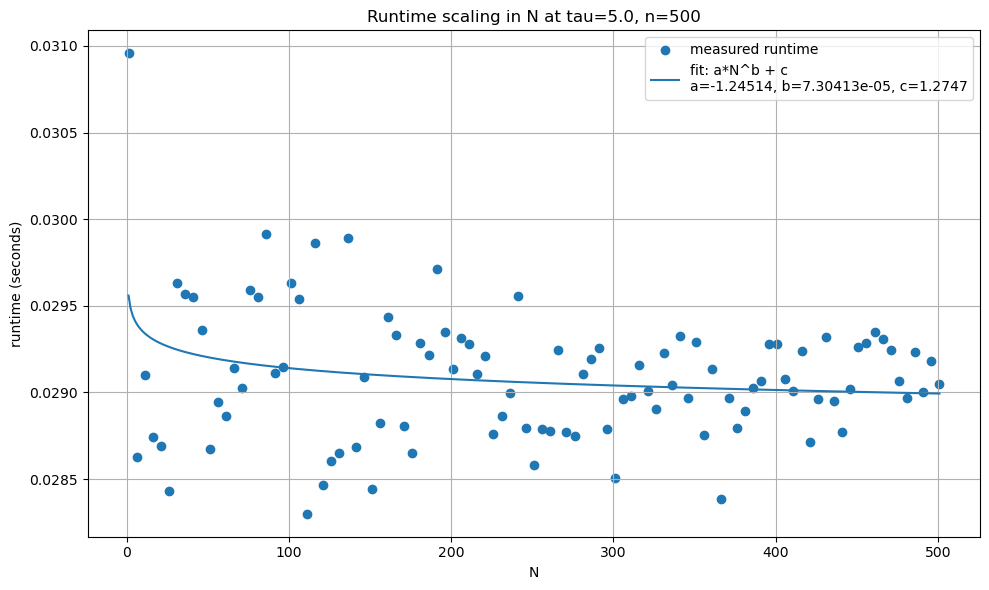

a = -1.2451396899449938
b = 7.304133317321892e-05
c = 1.2746986840728423


In [128]:
runtime_scaling_N_plot(tau=5.0, n=500, Nstart=1, Nend=501, Nstep=5, repeats=3)